In [1]:
import pandas as pd
import numpy as np

import pickle

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

In [2]:
test_df = pd.read_csv("../data/processed/test.csv")

In [3]:
test_df.shape

(15200, 171)

In [4]:
x_test = test_df.drop(columns=["class"])

y_test = test_df["class"]

In [6]:
with open("../models/final_xgboost_model.pkl", "rb") as file:
    final_xgb = pickle.load(file)

In [7]:
y_pred = final_xgb.predict(x_test)

In [8]:
print(y_pred[:10])

[0 0 0 0 0 0 0 0 0 0]


##### Accuracy

In [10]:
accuracy = accuracy_score(y_test,y_pred)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

Accuracy: 0.9934868421052632
Accuracy: 99.34868421052632 %


##### Precision

In [11]:
precision = precision_score(y_test,y_pred)

print("Precision:", precision)

Precision: 0.803448275862069


##### Recall

In [12]:
recall = recall_score(y_test,y_pred)

print("Recall:", recall)

Recall: 0.8472727272727273


##### F1_Score

In [13]:
f1 = f1_score(y_test,y_pred)

print("F1 Score:", f1)

F1 Score: 0.8247787610619469


##### Classification Report

In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14925
           1       0.80      0.85      0.82       275

    accuracy                           0.99     15200
   macro avg       0.90      0.92      0.91     15200
weighted avg       0.99      0.99      0.99     15200



##### Confusion matrix

In [15]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[14868    57]
 [   42   233]]


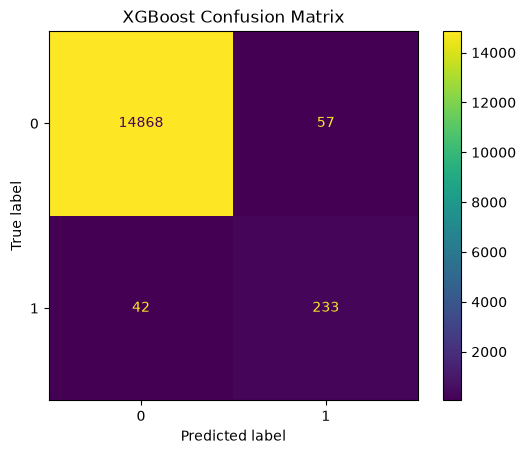

In [16]:
display = ConfusionMatrixDisplay(confusion_matrix=cm)

display.plot()

plt.title("XGBoost Confusion Matrix")

plt.show()

In [17]:
y_probability = final_xgb.predict_proba(x_test)[:, 1]

In [18]:
roc_auc = roc_auc_score(y_test,y_probability)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9927515151515152


In [21]:
fpr, tpr, thresholds = roc_curve(y_test,y_probability)

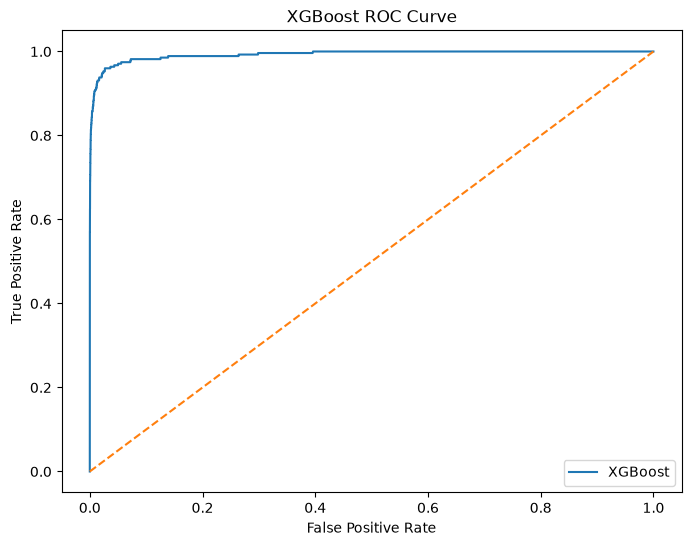

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

In [23]:
print("Final XGBoost Results")
print("----------------------")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Final XGBoost Results
----------------------
Accuracy : 0.9934868421052632
Precision: 0.803448275862069
Recall   : 0.8472727272727273
F1 Score : 0.8247787610619469
ROC-AUC  : 0.9927515151515152
